## Memory - Performance

Measure how performance changes with the size of DF

In [4]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# import our utilities
from util_jupyter import *
from util_models import *
from mybag import *

In [9]:
%%time
bag = MyBunch()
qt = 10**6 # million
for ii in [1,2,4,8,16,32,64,128]: # ,256,512,1024]:
    N = qt*ii
    print("Creating DF with %s rows" % commify(N))
    f1 = np.random.normal(loc=2.5,scale=1.0, size=N)
    bag["df_%d"%ii] = pd.DataFrame({'F1':f1, 'F2':f1*2.0, 'F3':f1*3.0})
print(bag)

Creating DF with 1,000,000 rows
Creating DF with 2,000,000 rows
Creating DF with 4,000,000 rows
Creating DF with 8,000,000 rows
Creating DF with 16,000,000 rows
Creating DF with 32,000,000 rows
Creating DF with 64,000,000 rows
Creating DF with 128,000,000 rows

df_1   = (df - 1000000 rows)
df_128 = (df - 128000000 rows)
df_16  = (df - 16000000 rows)
df_2   = (df - 2000000 rows)
df_32  = (df - 32000000 rows)
df_4   = (df - 4000000 rows)
df_64  = (df - 64000000 rows)
df_8   = (df - 8000000 rows)

CPU times: user 17.1 s, sys: 6.93 s, total: 24 s
Wall time: 17 s


In [10]:
%%time
metrics = []
for nn in bag.keys():
    ii = nn.split("_")[1]
    print(nn,ii)
    t1 = time.time()
    df = bag[nn].copy()
    df["cc"] = df['F1']*2.0
    del df
    dt = time.time() - t1
    metrics.append((nn.split("_")[1],dt))
    
print(metrics)

df_1 1
df_2 2
df_4 4
df_8 8
df_16 16
df_32 32
df_64 64
df_128 128
[('1', 0.03318929672241211), ('2', 0.04444003105163574), ('4', 0.08350920677185059), ('8', 0.1662740707397461), ('16', 0.5723180770874023), ('32', 0.6660170555114746), ('64', 3.8807709217071533), ('128', 10.08306622505188)]
CPU times: user 7.3 s, sys: 11.9 s, total: 19.2 s
Wall time: 15.5 s


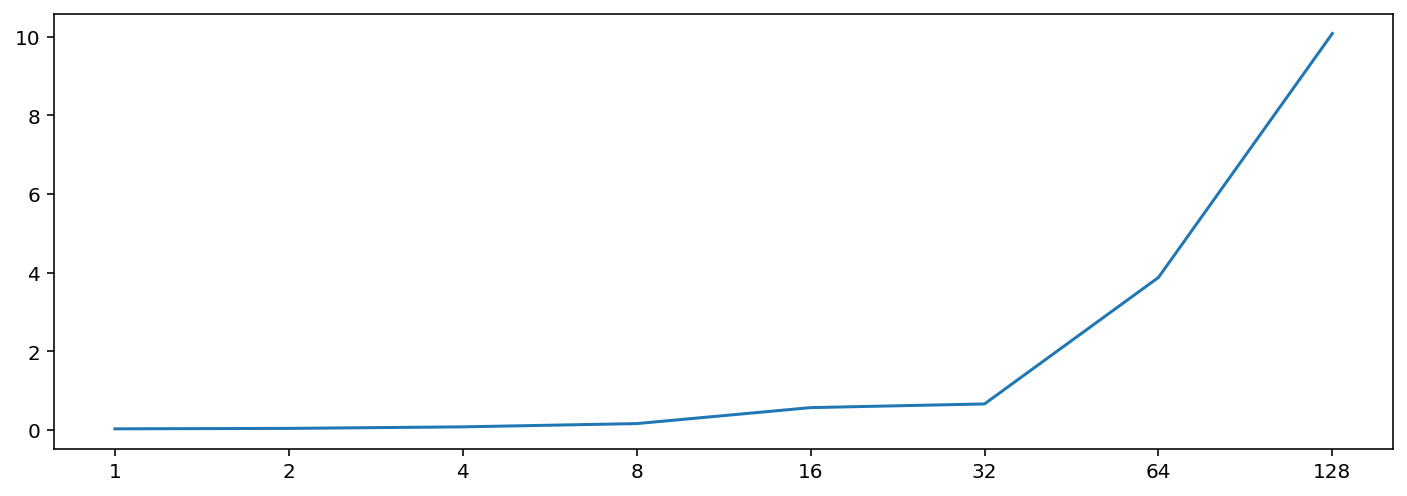

In [11]:
x = []
y = []
for ii in range(len(metrics)):
    xx,yy = metrics[ii]
    x.append(xx)
    y.append(yy)
plt.rcParams["figure.figsize"] = (12, 4) # (width, height)
fig, (ax1) = plt.subplots(nrows=1, ncols=1)
#ax1.set_yscale("log")
ax1.plot(x[:],y[:])
plt.show();